# Calculation of center of mass
This example shows how the function *get_com* is used to calculate the center of mass movement in one direction from hip and shoulder movement trajectories.

In [1]:
import pandas as pd
import balancepy.biomechanics as bm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# render plots as static image - only needed for documentation
import plotly.io as pio
pio.renderers.default = "svg"

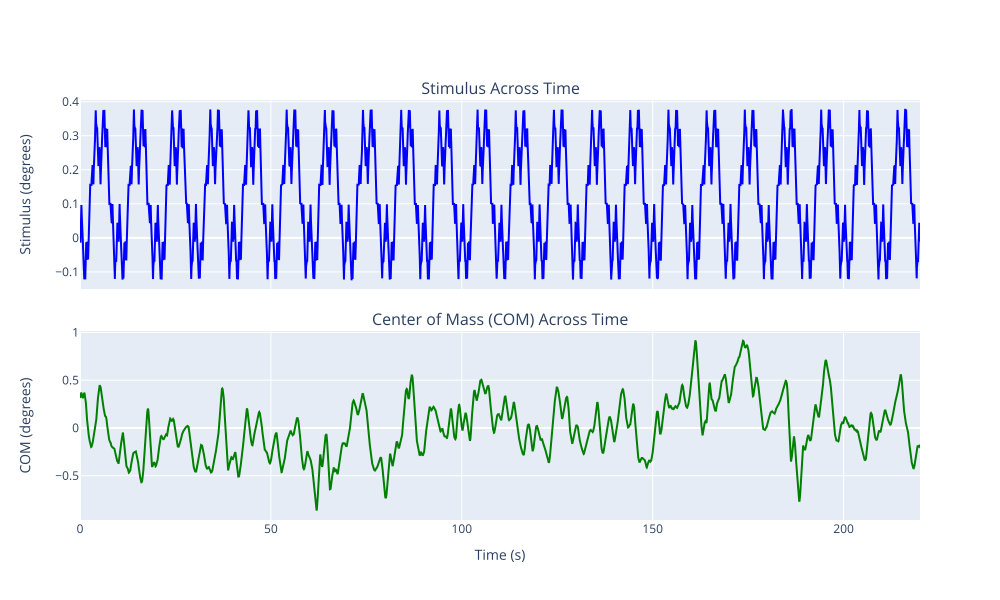

In [2]:

height = 1.75  # height in meters
weight = 70  # weight in kg

data = pd.read_csv('data/d1_vis1.csv')

time = data['time']
stimulus = data['analog2']
com = bm.get_com(data['shld_zpos'], data['shld_ypos'], data['hip_zpos'], data['hip_ypos'], height)


# Create subplots
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                    subplot_titles=("Stimulus Across Time", "Center of Mass (COM) Across Time"))

# Add stimulus plot
fig.add_trace(go.Scatter(x=time, y=stimulus, mode='lines', name='Stimulus', line=dict(color='blue')), row=1, col=1)

# Add COM plot
fig.add_trace(go.Scatter(x=time, y=com, mode='lines', name='COM', line=dict(color='green')), row=2, col=1)

# Update layout
fig.update_layout(height=600, width=1000, showlegend=False)
fig.update_xaxes(title_text="Time (s)", row=2, col=1)
fig.update_yaxes(title_text="Stimulus (degrees)", row=1, col=1)
fig.update_yaxes(title_text="COM (degrees)", row=2, col=1)

fig.show()
